In [4]:
%%javascript
IPython.OutputArea.prototype._should_scroll = function(lines) {
    return false;
}


<IPython.core.display.Javascript object>

In [6]:
#package imports
import sys,os, pickle, time, math
import csv
import scipy.io as sio
import scipy.stats 

import numpy as np
np.set_printoptions(precision = 3, threshold=np.inf)

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from sklearn.discriminant_analysis import LinearDiscriminantAnalysis 
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA

from utils import *
from TimeDomainFilter import TimeDomainFilter


In [3]:
### Load data
FILENAME = "_train_20230616_160240.mat"
NUM_CLASSES = 6
NUM_ELECTRODES = 8
emg_window_size = 40
emg_window_step = 10

td5 = TimeDomainFilter()

data = sio.loadmat(FILENAME)['train']


## Extract Features for training data
X = []
y = []
for trialnum in [00,1]:
    trial_data = data[0,trialnum][0][0]
for c in range(NUM_CLASSES): 
    class_data = []
    raw_data = trial_data[c]
    num_samples = raw_data.shape[0]
    idx = 0
    while idx + emg_window_size < num_samples:
        window = raw_data[idx:(idx+emg_window_size),:]
        time_domain = td5.filter( window ).flatten()
        class_data.append( np.hstack( time_domain ) )
        idx += emg_window_step
    X.append( np.vstack( class_data ) )
    y.append( c * np.ones( ( X[-1].shape[0], ) ) )
Xtrain = np.vstack( X )
ytrain = np.hstack( y )


X = []
y = []
for trialnum in [2]:
    trial_data = data[0,trialnum][0][0]
for c in range(NUM_CLASSES): 
    class_data = []
    raw_data = trial_data[c]
    num_samples = raw_data.shape[0]
    idx = 0
    while idx + emg_window_size < num_samples:
        window = raw_data[idx:(idx+emg_window_size),:]
        time_domain = td5.filter( window ).flatten()
        class_data.append( np.hstack( time_domain ) )
        idx += emg_window_step
    X.append( np.vstack( class_data ) )
    y.append( c * np.ones( ( X[-1].shape[0], ) ) )
Xtest = np.vstack( X )
ytest = np.hstack( y )


In [4]:

# Calculate Basis Transform
mdl = LinearDiscriminantAnalysis(n_components = 3)
mdl.fit(Xtrain, ytrain )


print(f'Classification accuracy with LDA is {100*mdl.score(Xtest, ytest)}%' )


xform_test = mdl.transform(Xtest)


Classification accuracy with LDA is 99.70414201183432%


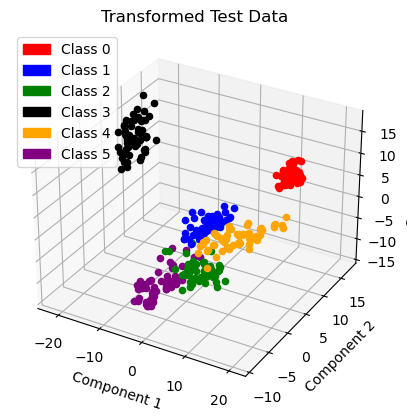

In [5]:

#x_test_xform = mdl.transform(Xtest)

fig = plt.figure()
ax = fig.add_subplot(projection='3d')



colors = ["red", "blue", "green", "black", "orange", "purple"]

legend_patches = []
for i in range(NUM_CLASSES):
    legend_patches.append(mpatches.Patch(color=colors[i], label=f'Class {i}'))


for pt in range(len(ytest)):
    c = ytest[pt]
    
    #print(c, colors[int(c%6)], xform_test[pt,:])
    ax.scatter(xform_test[pt, 0],
               xform_test[pt, 1],
               xform_test[pt, 2],
               color=colors[int(c%6)] ) 
ax.set_title("Transformed Test Data")
ax.set_xlabel("Component 1")
ax.set_ylabel("Component 2")
ax.set_zlabel("Component 3")

ax.legend(handles=legend_patches)

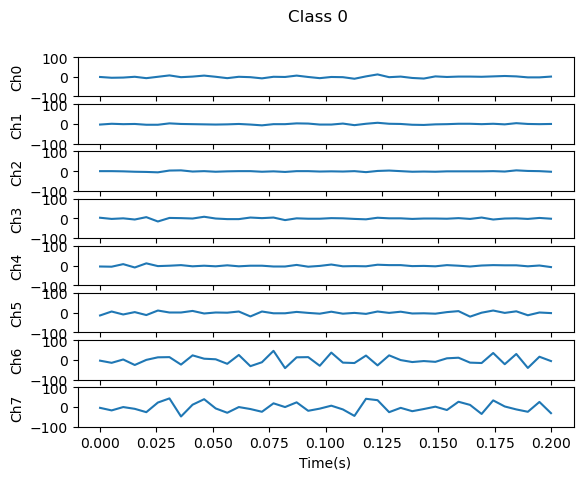

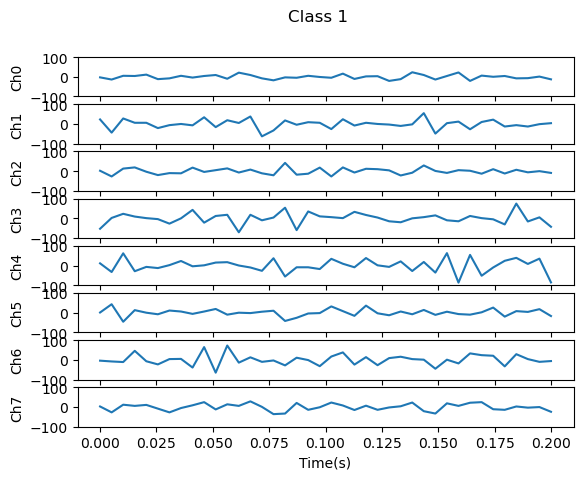

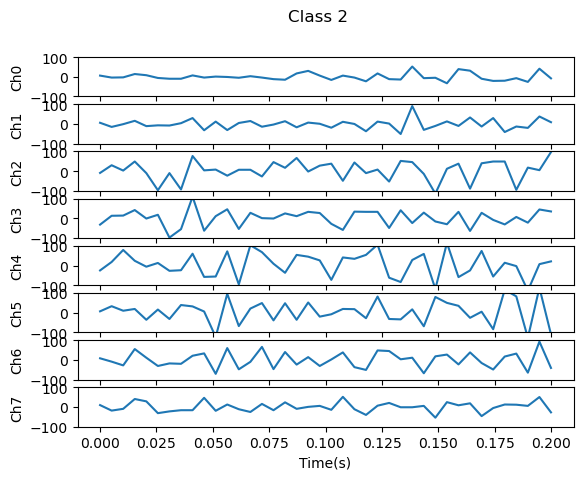

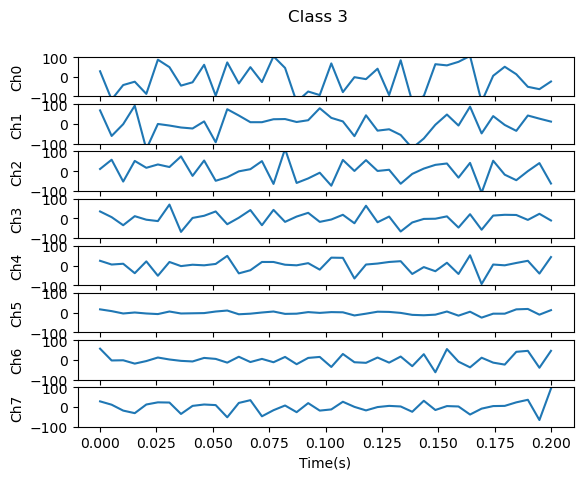

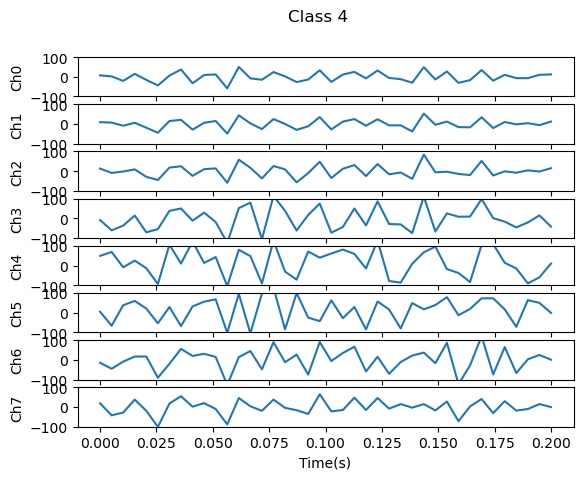

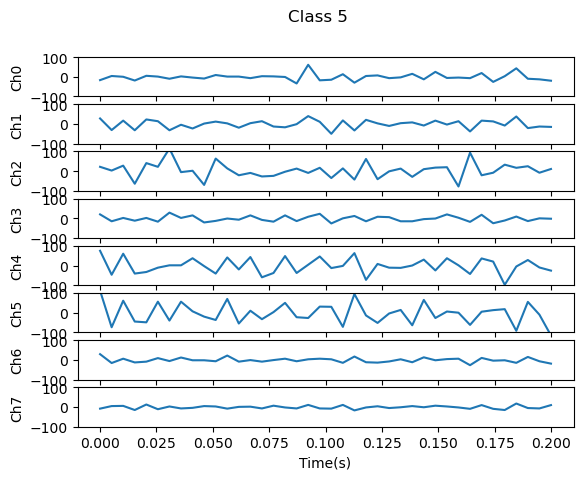

In [6]:
### Plot some Raw EMG 

for c in range(NUM_CLASSES):
    fig,axs = plt.subplots(8)
    fig.suptitle(f'Class {c}')

    #print(np.shape(trial_data[c]), idx)
    t = np.linspace(0,emg_window_size*1/200, emg_window_size)
    
    for e in range(NUM_ELECTRODES):
        axs[e].plot( t, trial_data[c][0:emg_window_size, e]  )
        axs[e].set_ylim([-100,100])
        axs[e].set_ylabel(f'Ch{e}')

    axs[e].set_xlabel("Time(s)")